In [17]:
import ee
import geopandas as gpd
from src.data import gedi_pipeline
from src.data.ee import lcms_import
from src.processing.regen import regen_analysis
from src.data.fire_perimeters import FirePerimeters, FirePerimetersDB, Fire, match_gedi_to_raster, FireRastersDB
from src.data import fire_perimeters
from src.data import gedi_raster_matching
from src.data import raster
import rasterio as rio
import matplotlib.pyplot as plt
import pandas as pd
from src.constants import DATA_PATH, USER_PATH
from fitter import Fitter, get_common_distributions, get_distributions
import seaborn as sns
from fastai.tabular.all import save_pickle, load_pickle
from src.visualization.dists import plot_pdf
from src.data import gedi_pipeline
import seaborn as sns
import numpy as np

sns.set_theme()
sns.set_palette = "Set2"

import importlib
importlib.reload(regen_analysis)
importlib.reload(gedi_pipeline)
importlib.reload(gedi_raster_matching)
importlib.reload(raster)
importlib.reload(fire_perimeters)

2023-11-03 21:05:33,136 DEBUG: Logger /home/jk871/fire-regen/src/data/gedi_pipeline.py already set up. [in get_logger at /home/jk871/fire-regen/src/utils/logging_util.py:51]
2023-11-03 21:05:33,139 DEBUG: Logger /home/jk871/fire-regen/src/data/gedi_raster_matching.py already set up. [in get_logger at /home/jk871/fire-regen/src/utils/logging_util.py:51]
2023-11-03 21:05:33,141 DEBUG: Logger /home/jk871/fire-regen/src/data/fire_perimeters.py already set up. [in get_logger at /home/jk871/fire-regen/src/utils/logging_util.py:51]


<module 'src.data.fire_perimeters' from '/home/jk871/fire-regen/src/data/fire_perimeters.py'>

In [3]:
gedi_recovery = regen_analysis.process_all_fires_with_rf_control_per_burn_year_rh98(f"{DATA_PATH}/rf/rh98/burned/", f"{DATA_PATH}/rf/rh98/models_log")


Process fires for year 1985.
matching shots within fire
Processing data
Run RF to predict control RH98.
Process fires for year 1986.
matching shots within fire
Processing data
Run RF to predict control RH98.
Process fires for year 1987.
matching shots within fire
Processing data
Run RF to predict control RH98.
Process fires for year 1988.
matching shots within fire
Processing data
Run RF to predict control RH98.
Process fires for year 1989.
matching shots within fire
Processing data
Run RF to predict control RH98.
Process fires for year 1990.
matching shots within fire
Processing data
Run RF to predict control RH98.
Process fires for year 1991.
matching shots within fire
Processing data
Run RF to predict control RH98.
Process fires for year 1992.
matching shots within fire
Processing data
Run RF to predict control RH98.
Process fires for year 1993.
matching shots within fire
Processing data
Run RF to predict control RH98.
Process fires for year 1994.
matching shots within fire
Processi

<Axes: xlabel='time_since_burn', ylabel='rh98_control'>

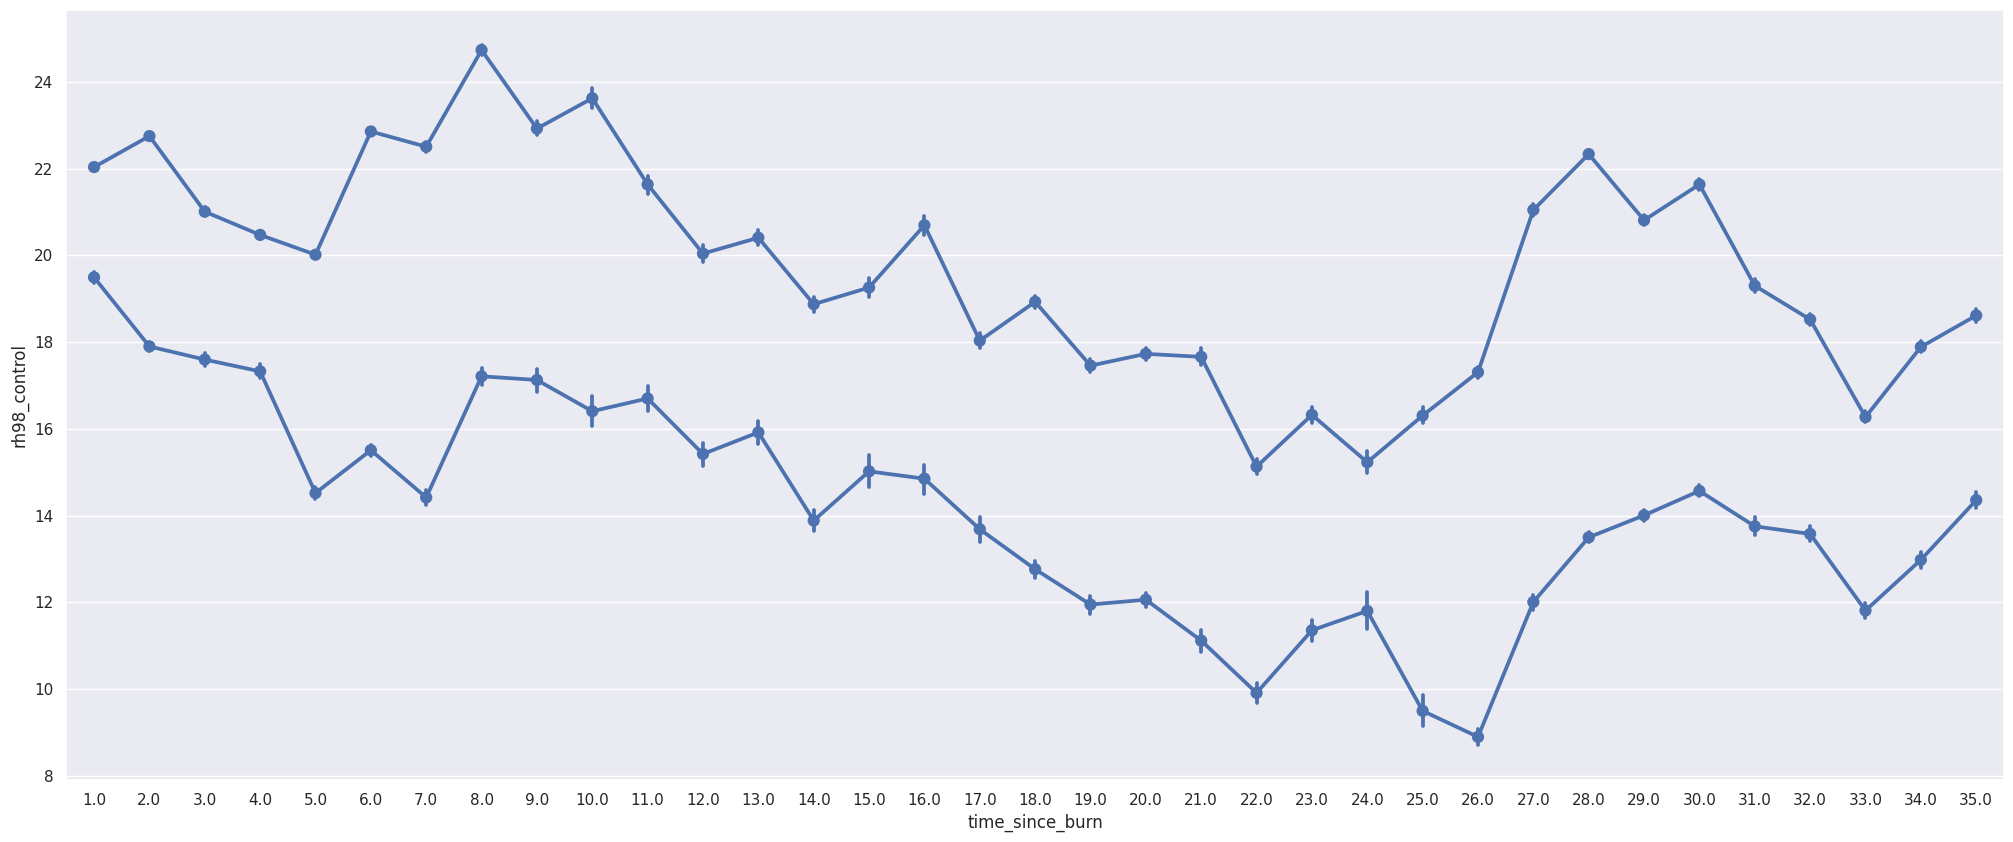

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(25, 10))
sns.pointplot(gedi_recovery, x='time_since_burn', y='rh_98')
sns.pointplot(gedi_recovery, x='time_since_burn', y='rh98_control')

(0.0, 1.3)

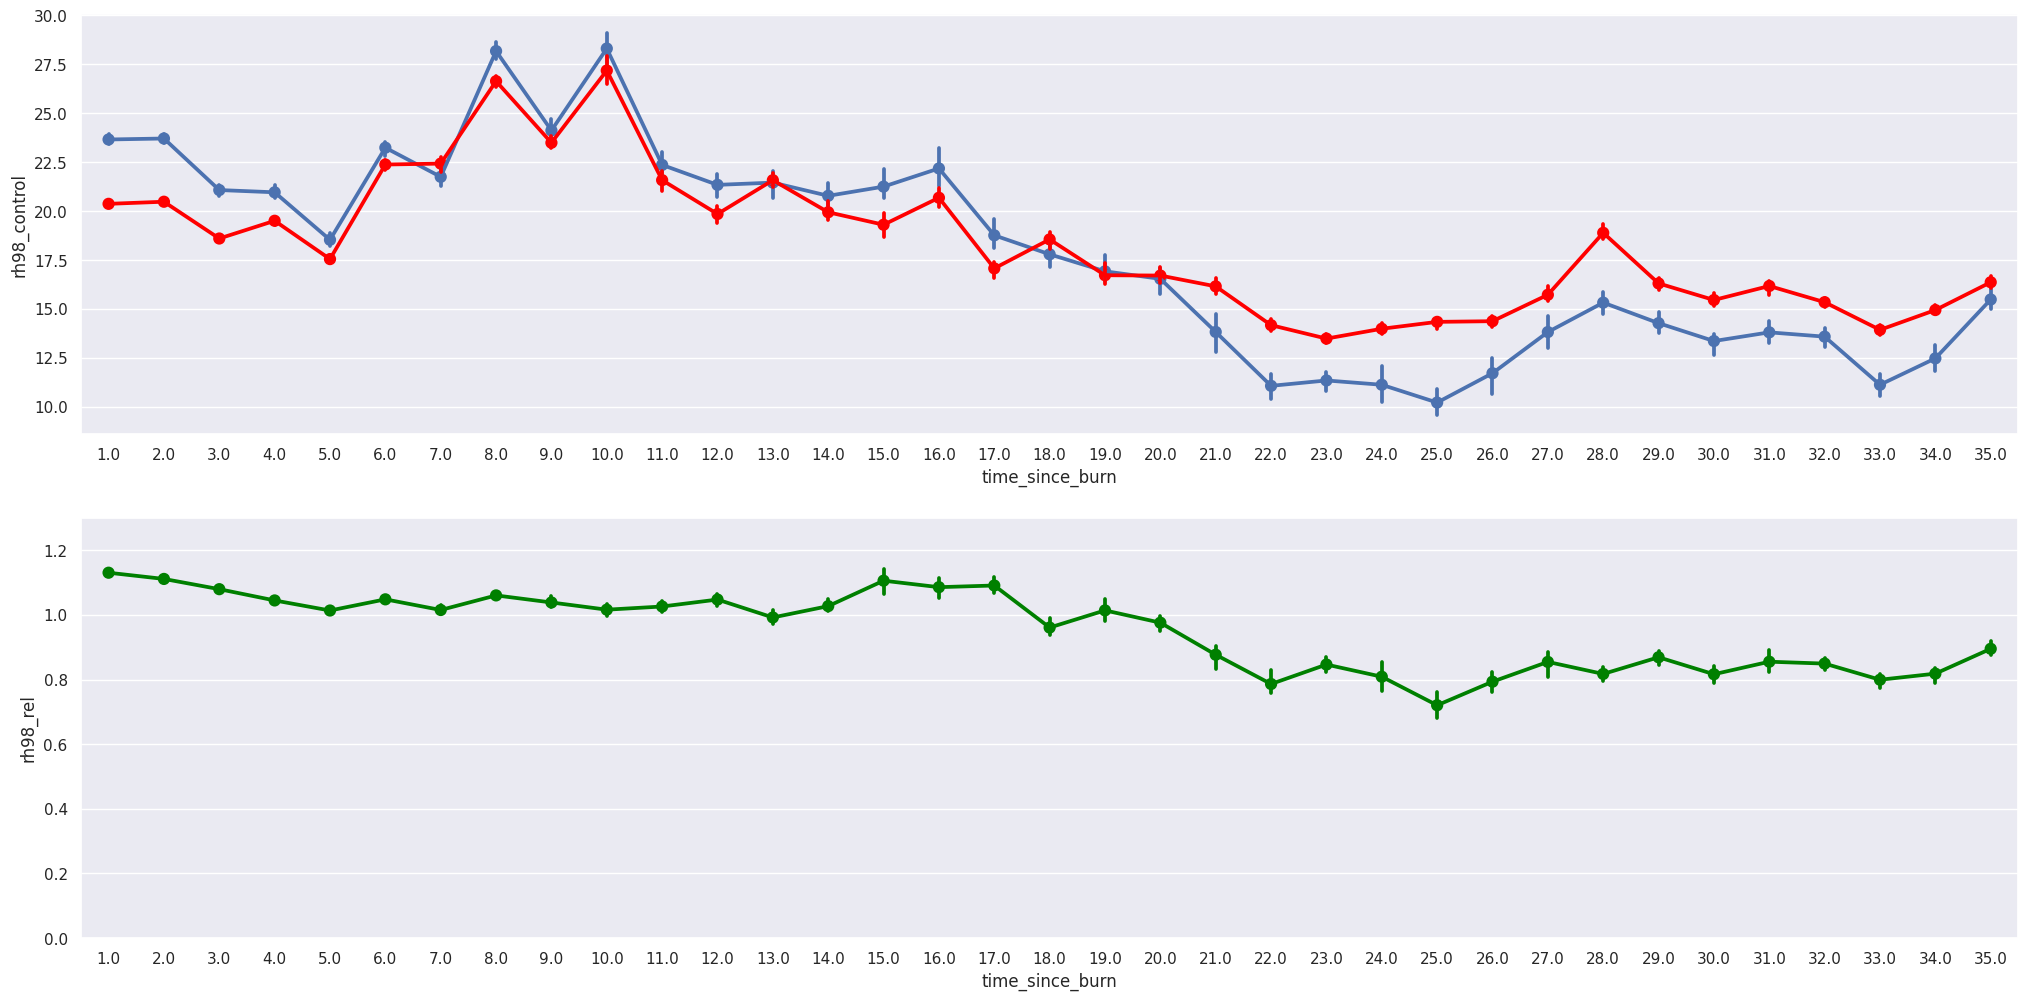

In [25]:
fig, ax = plt.subplots(2, 1, figsize=(25, 12))
df = gedi_recovery[gedi_recovery.severity == 2]
sns.pointplot(df, x='time_since_burn', y='rh_98', estimator="median", ax=ax[0])
sns.pointplot(df, x='time_since_burn', y='rh98_control', color="red", estimator="median", ax=ax[0])
sns.pointplot(df, x='time_since_burn', y='rh98_rel', color="green", estimator="median", ax=ax[1])
ax[1].set_ylim((0, 1.3))

(0.0, 1.3)

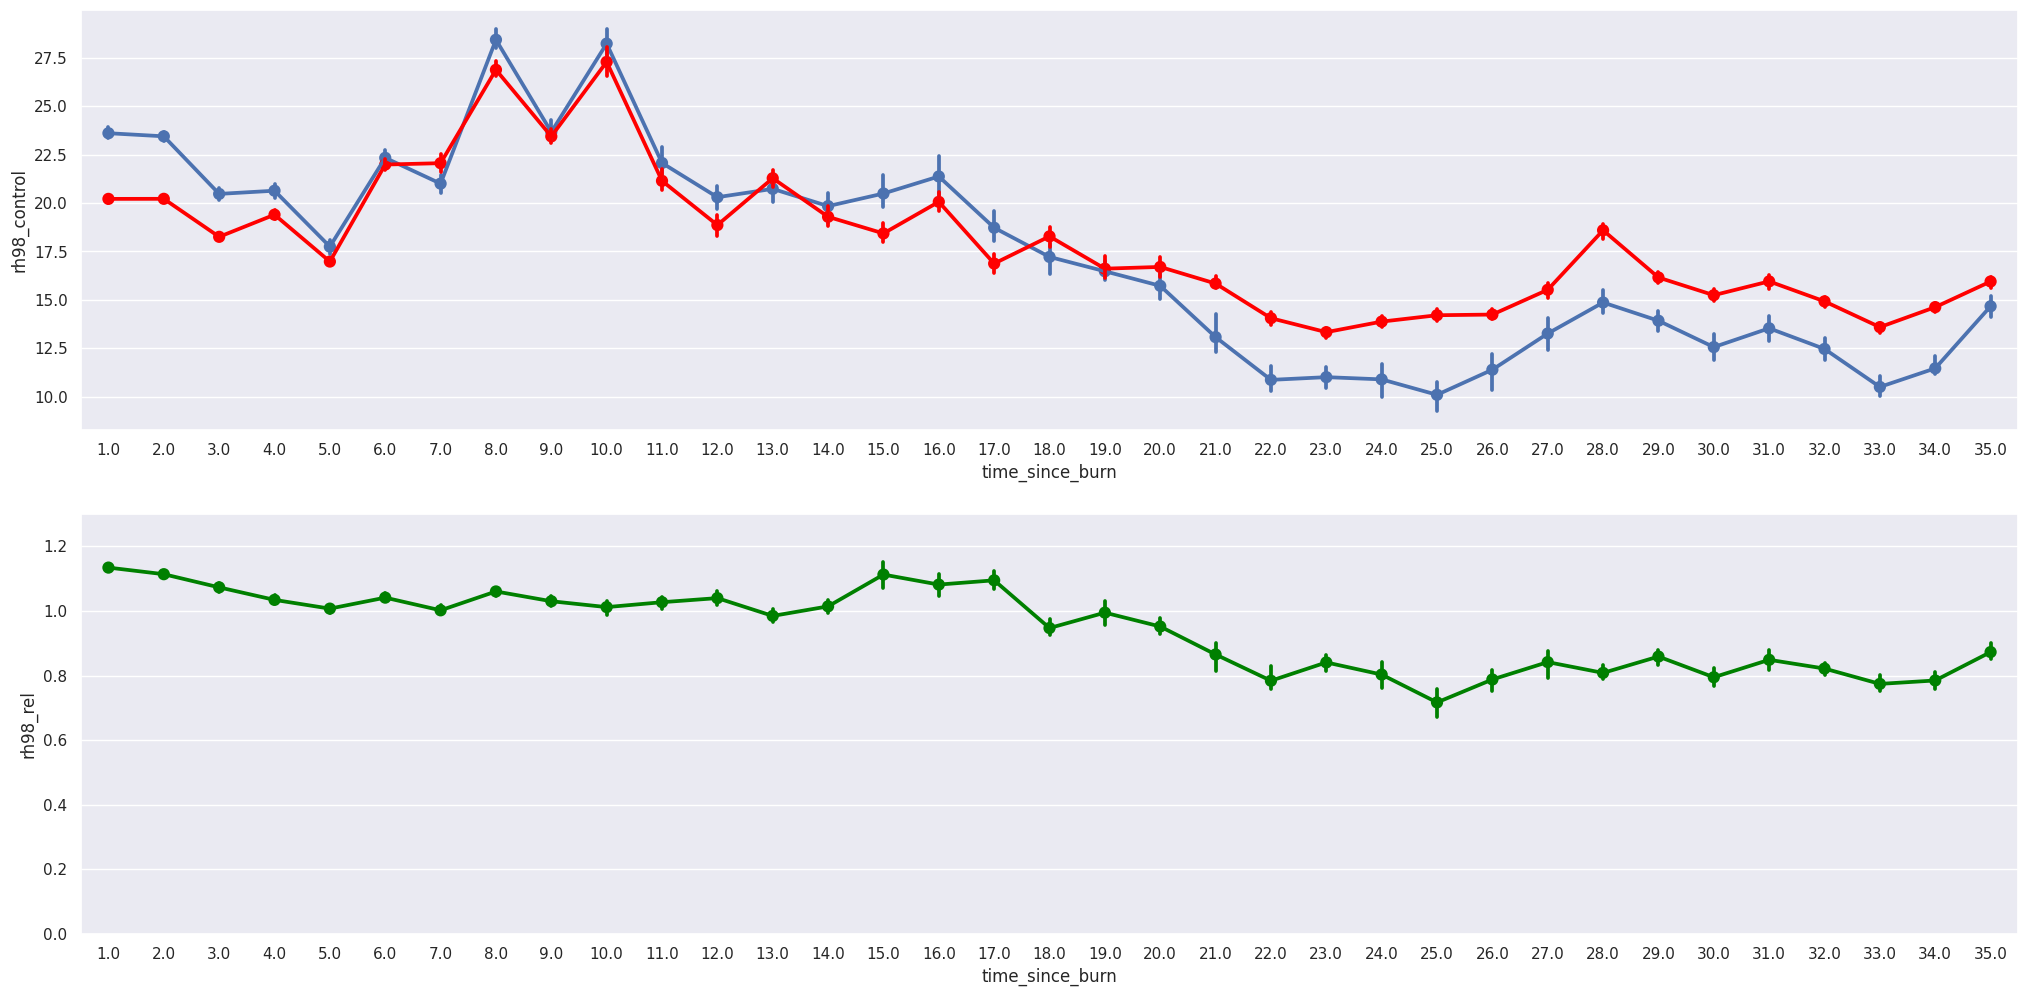

In [32]:
fig, ax = plt.subplots(2, 1, figsize=(25, 12))
df = gedi_recovery[gedi_recovery.severity == 2]
df = df[df.slope_median < 30]
sns.pointplot(df, x='time_since_burn', y='rh_98', estimator="median", ax=ax[0])
sns.pointplot(df, x='time_since_burn', y='rh98_control', color="red", estimator="median", ax=ax[0])
sns.pointplot(df, x='time_since_burn', y='rh98_rel', color="green", estimator="median", ax=ax[1])
ax[1].set_ylim((0, 1.3))

(0.0, 1.3)

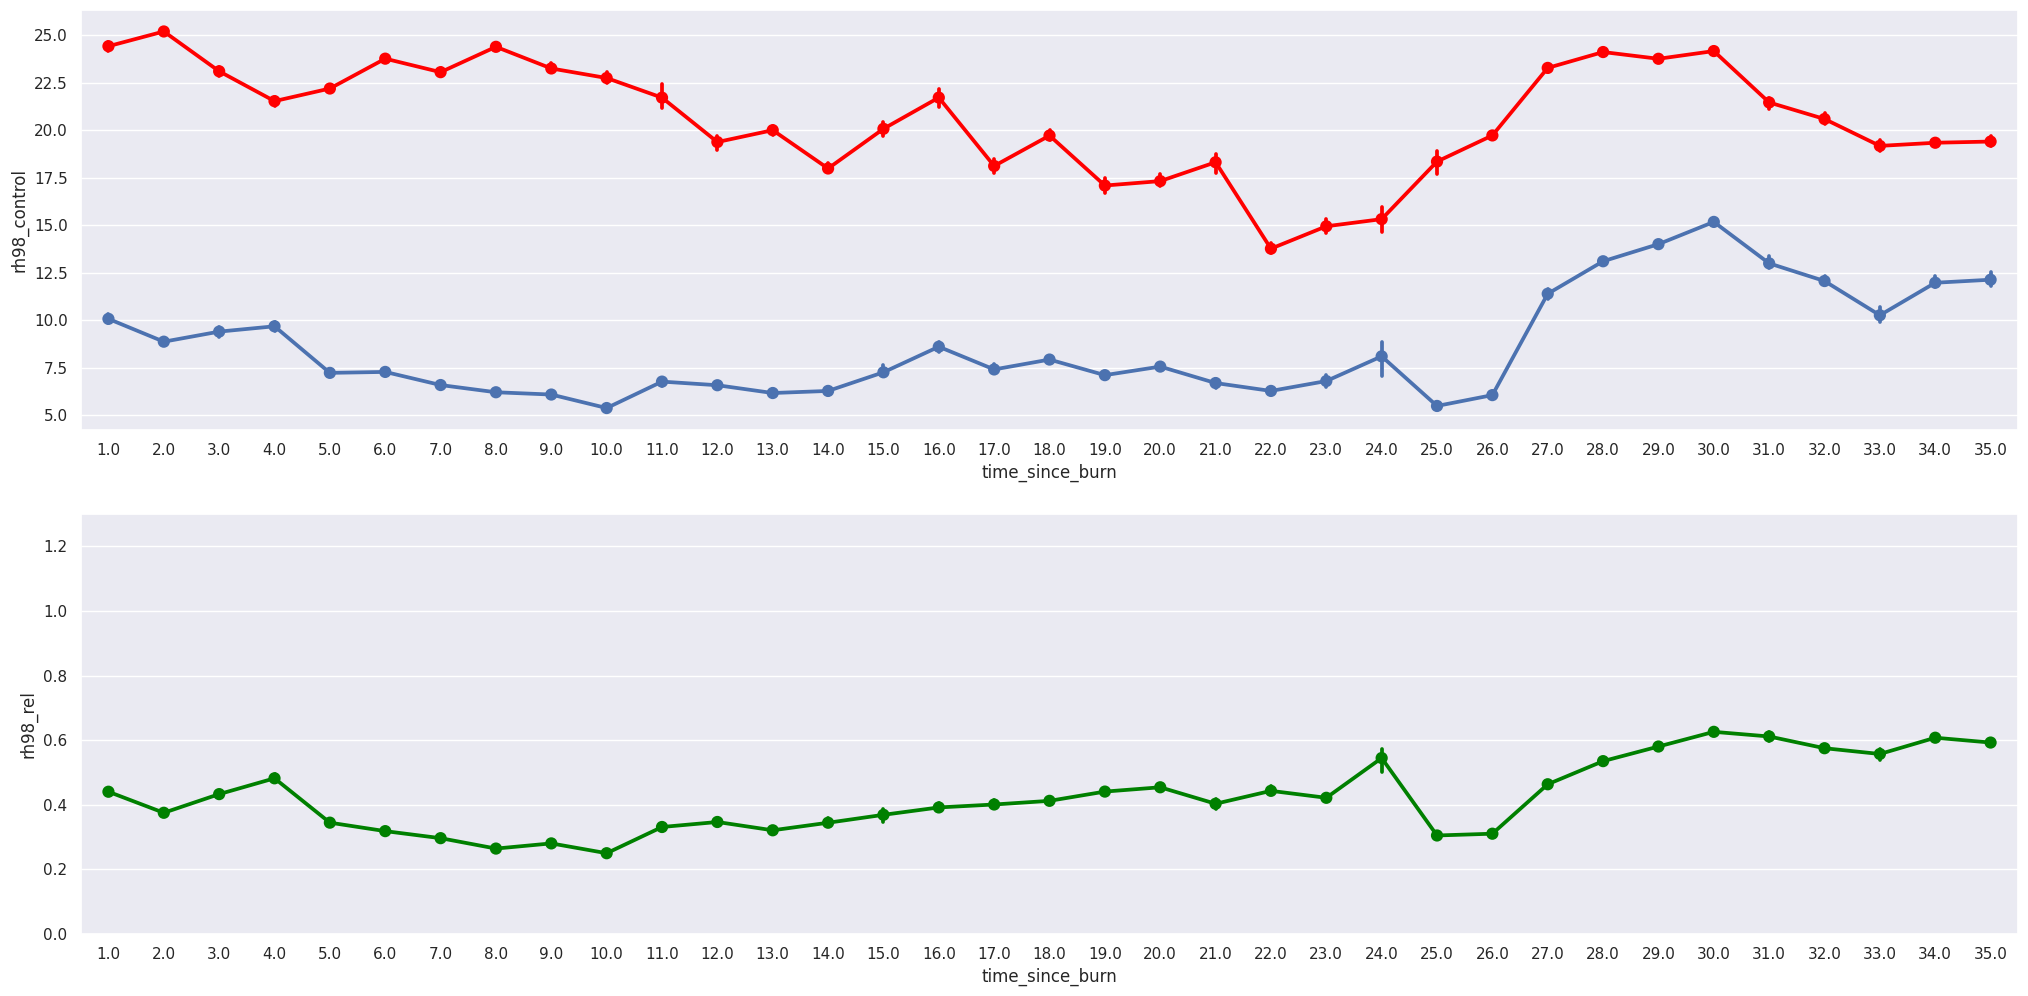

In [33]:
fig, ax = plt.subplots(2, 1, figsize=(25, 12))
df = gedi_recovery[gedi_recovery.severity == 4]
df = df[df.slope_median < 30]
sns.pointplot(df, x='time_since_burn', y='rh_98', estimator="median", ax=ax[0])
sns.pointplot(df, x='time_since_burn', y='rh98_control', color="red", estimator="median", ax=ax[0])
sns.pointplot(df, x='time_since_burn', y='rh98_rel', color="green", estimator="median", ax=ax[1])
ax[1].set_ylim((0, 1.3))

(0.0, 1.3)

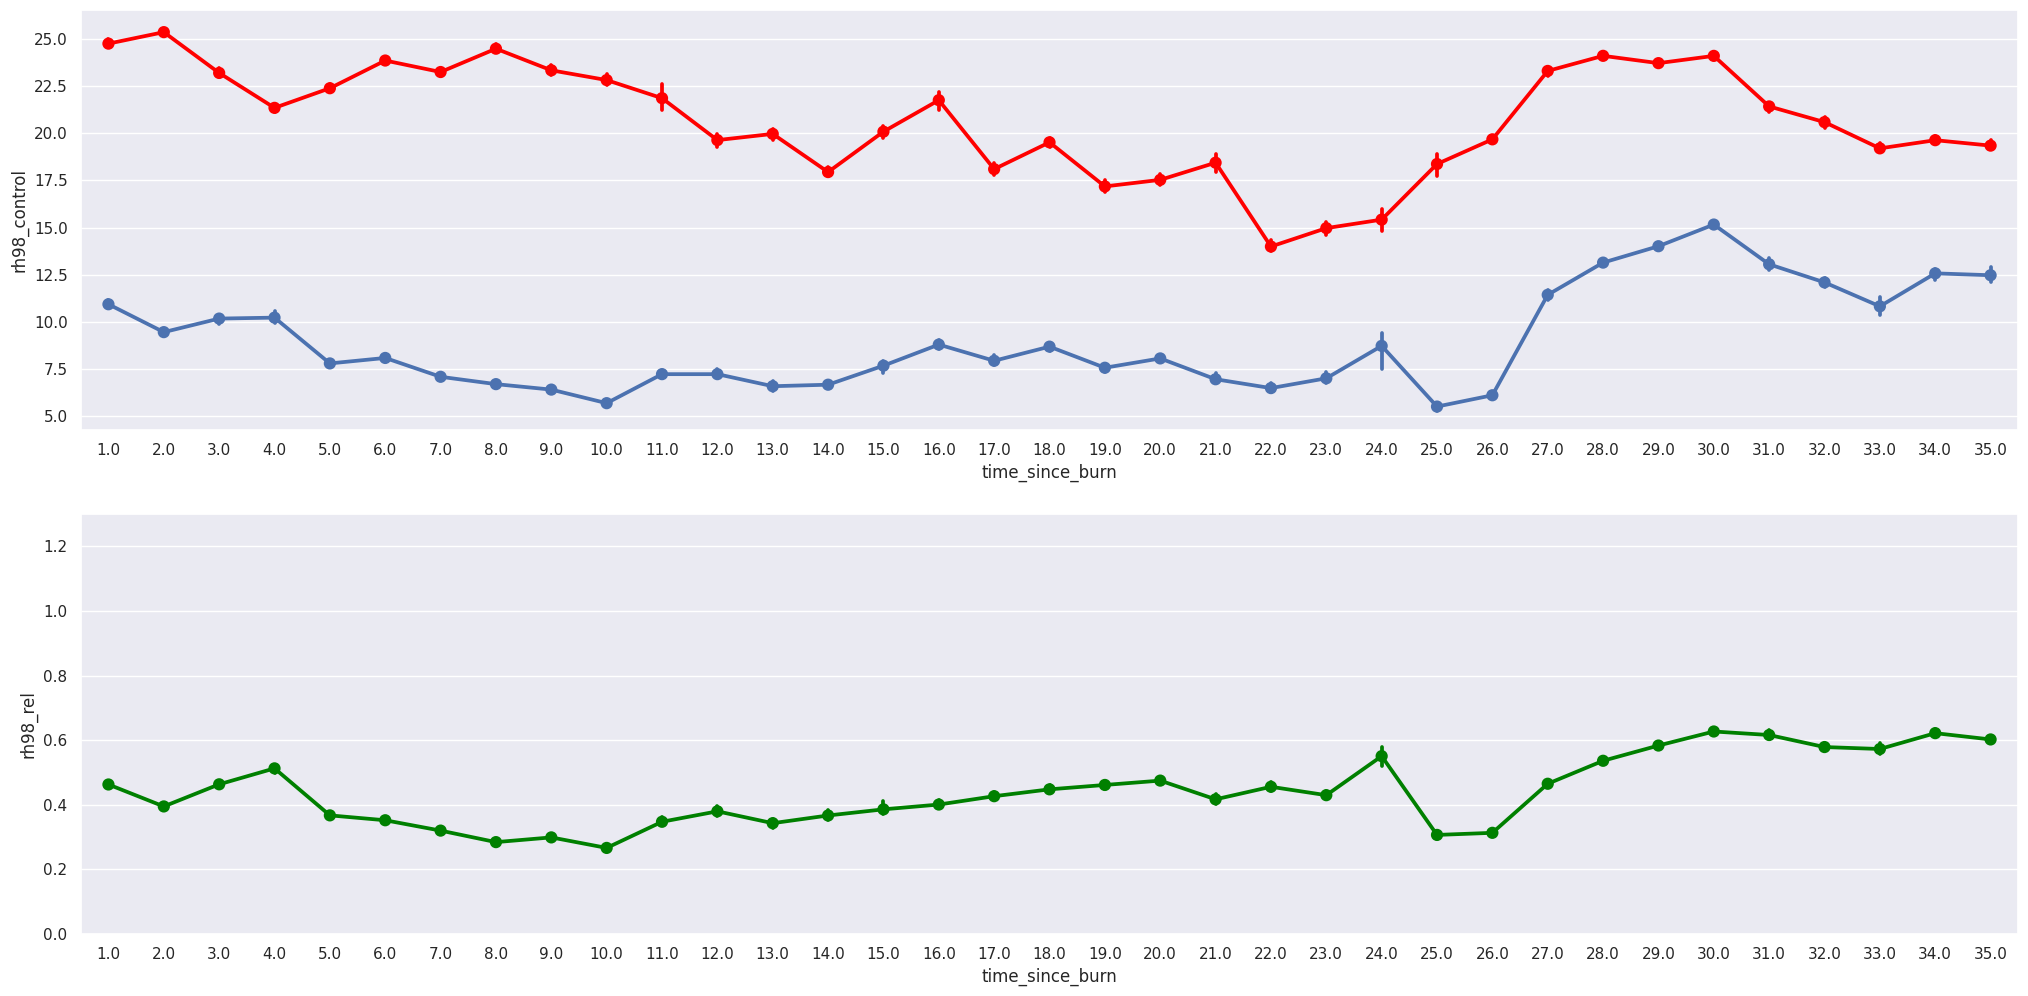

In [31]:
fig, ax = plt.subplots(2, 1, figsize=(25, 12))
df = gedi_recovery[gedi_recovery.severity == 4]
df = df[df.slope_median < 30]
sns.pointplot(df, x='time_since_burn', y='rh_98', estimator="median", ax=ax[0])
sns.pointplot(df, x='time_since_burn', y='rh98_control', color="red", estimator="median", ax=ax[0])
sns.pointplot(df, x='time_since_burn', y='rh98_rel', color="green", estimator="median", ax=ax[1])
ax[1].set_ylim((0, 1.3))

(0.0, 1.3)

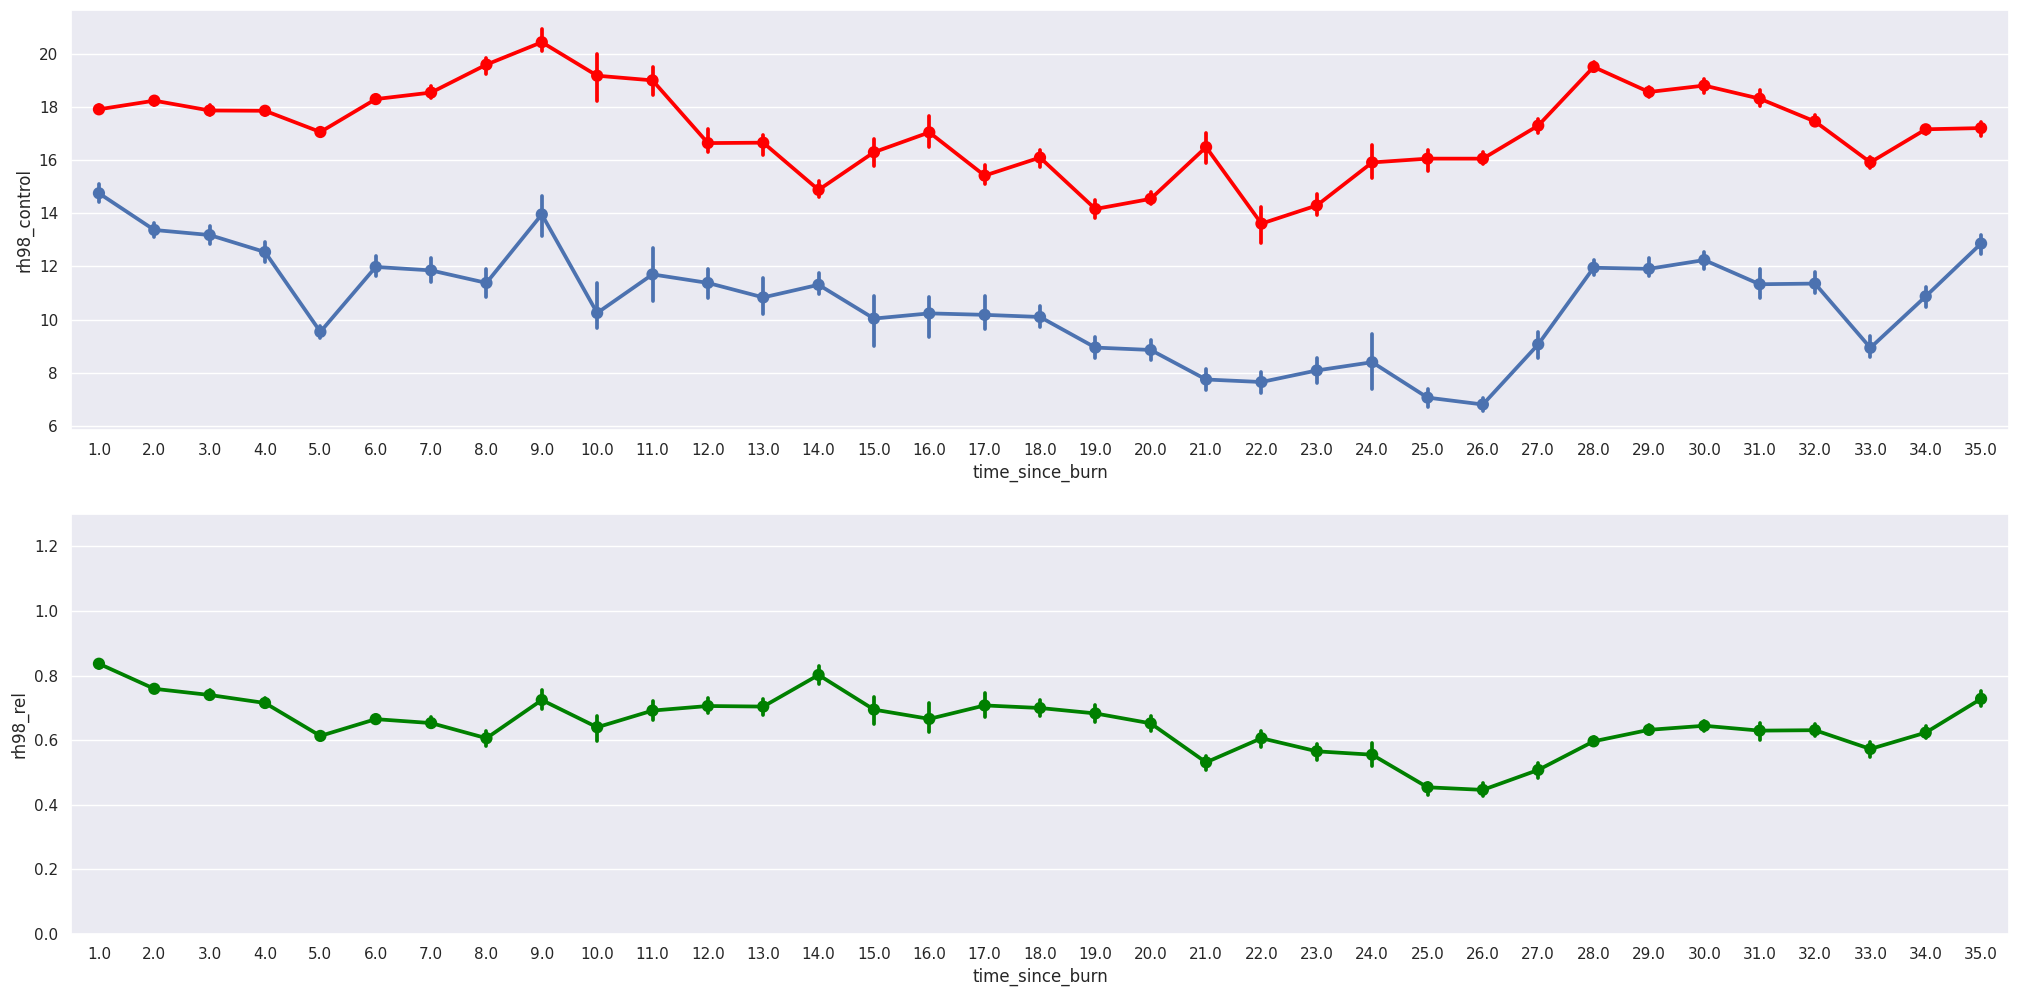

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(25, 12))
df = gedi_recovery[gedi_recovery.severity == 3]
sns.pointplot(df, x='time_since_burn', y='rh_98', estimator="median", ax=ax[0])
sns.pointplot(df, x='time_since_burn', y='rh98_control', color="red", estimator="median", ax=ax[0])
sns.pointplot(df, x='time_since_burn', y='rh98_rel', color="green", estimator="median", ax=ax[1])
ax[1].set_ylim((0, 1.3))

In [28]:
low_severity = gedi_recovery[gedi_recovery.severity == 2]
low_10 = low_severity[low_severity.time_since_burn < 11]
low_20 = low_severity[(low_severity.time_since_burn < 32) & (low_severity.time_since_burn >= 22)]

(0.0, 5.0)

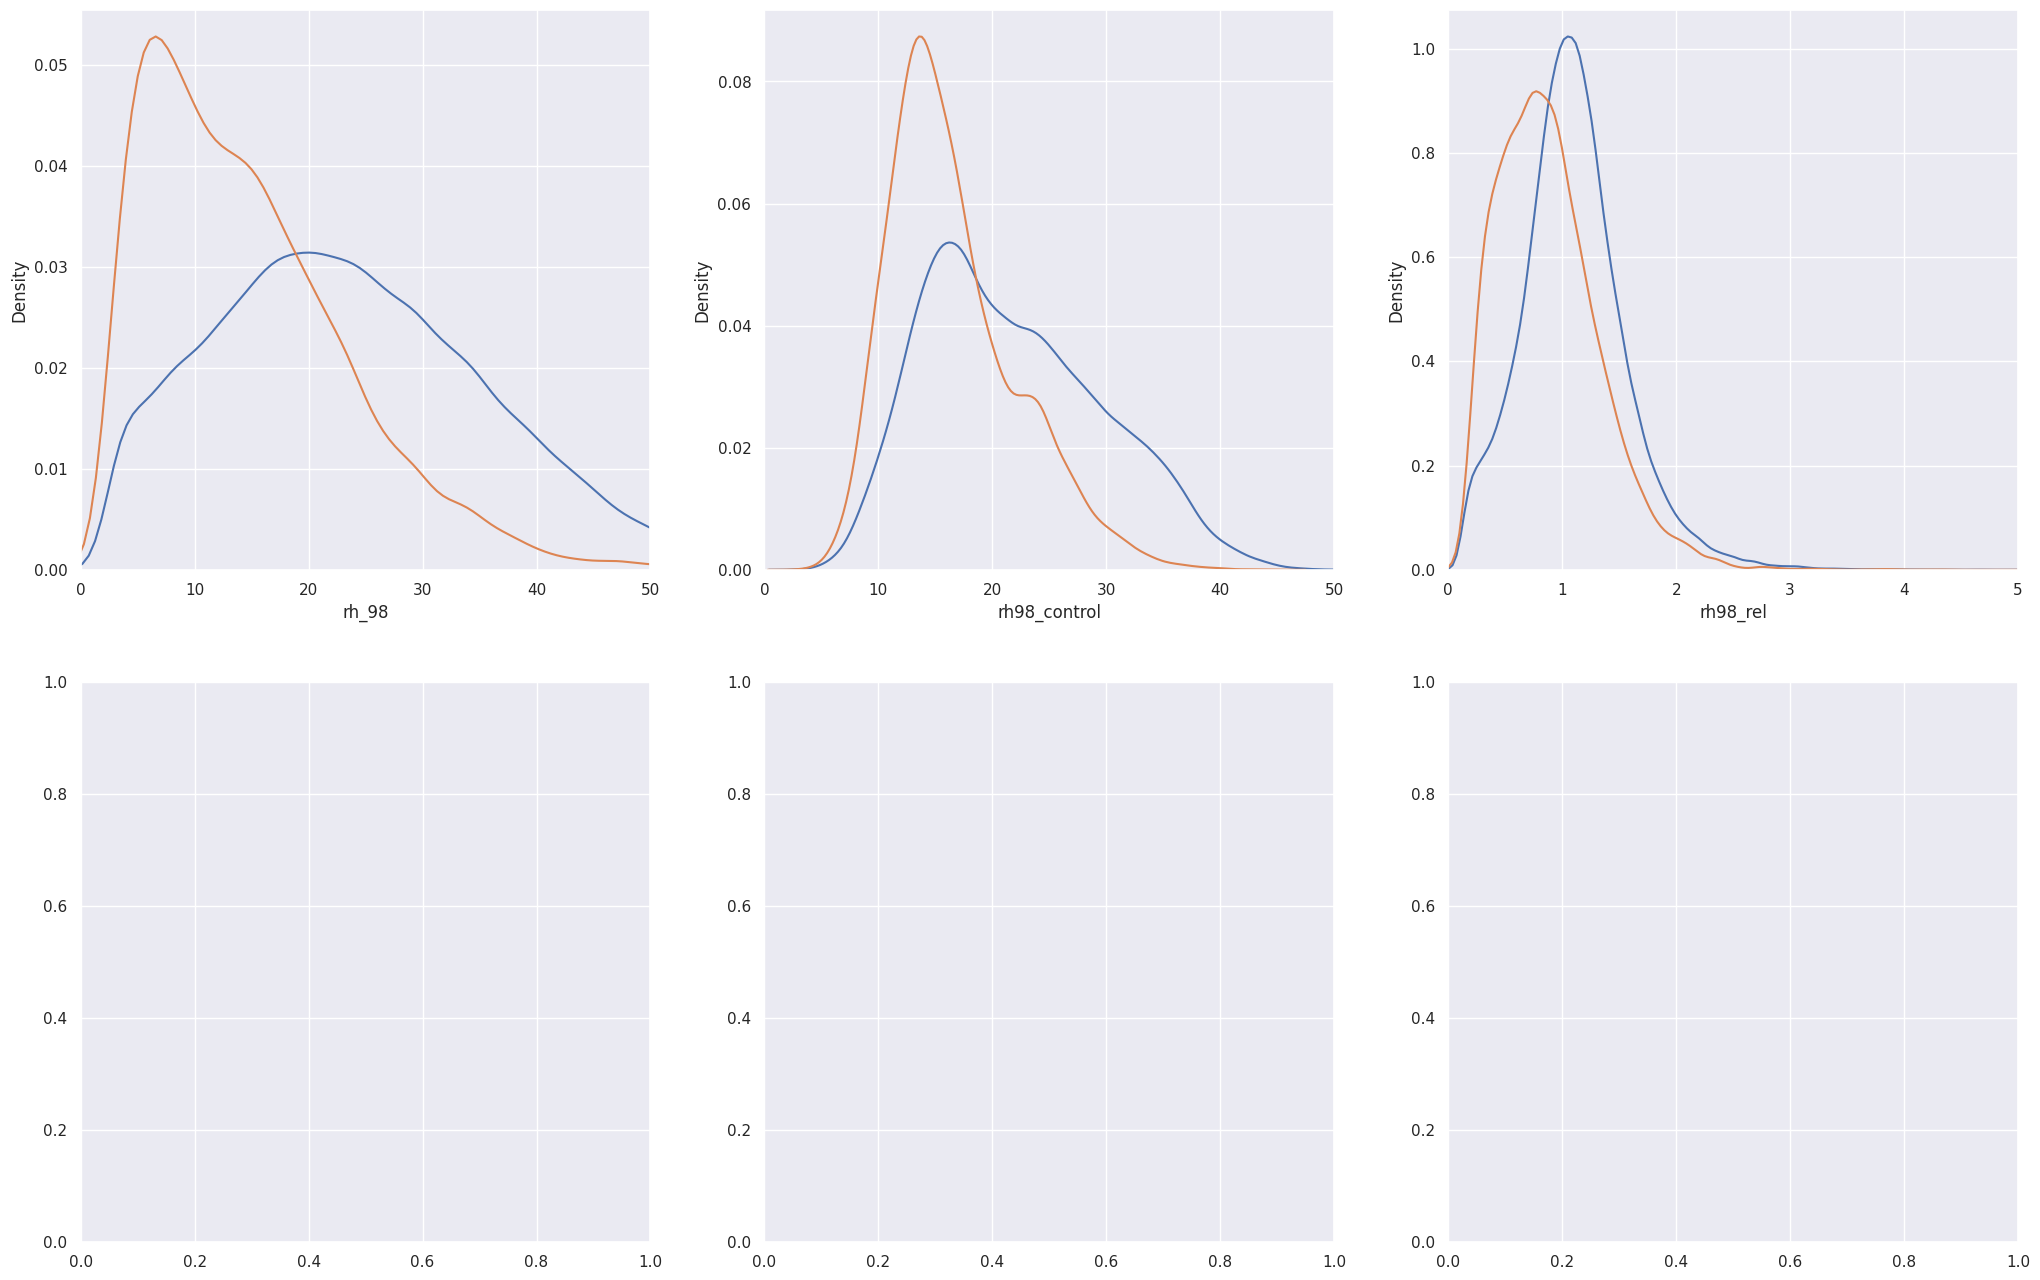

In [30]:
fig, ax = plt.subplots(2, 3, figsize=(25, 16))
sns.kdeplot(low_10, x="rh_98", ax=ax[0][0])
sns.kdeplot(low_20, x="rh_98", ax=ax[0][0])
sns.kdeplot(low_10, x="rh98_control", ax=ax[0][1])
sns.kdeplot(low_20, x="rh98_control", ax=ax[0][1])
sns.kdeplot(low_10, x="rh98_rel", ax=ax[0][2])
sns.kdeplot(low_20, x="rh98_rel", ax=ax[0][2])
#sns.kdeplot(low_10, x="NDVI_mean", ax=ax[1][0])
#sns.kdeplot(low_20, x="NDVI_mean", ax=ax[1][0])
#sns.kdeplot(low_10, x="NDVI_control", ax=ax[1][1])
#sns.kdeplot(low_20, x="NDVI_control", ax=ax[1][1])
#sns.kdeplot(low_10, x="NDVI_rel", ax=ax[1][2])
#sns.kdeplot(low_20, x="NDVI_rel", ax=ax[1][2])
ax[0][0].set_xlim((0, 50))
ax[0][1].set_xlim((0, 50))
ax[0][2].set_xlim((0, 5))

<Axes: xlabel='time_since_burn', ylabel='rh98_control'>

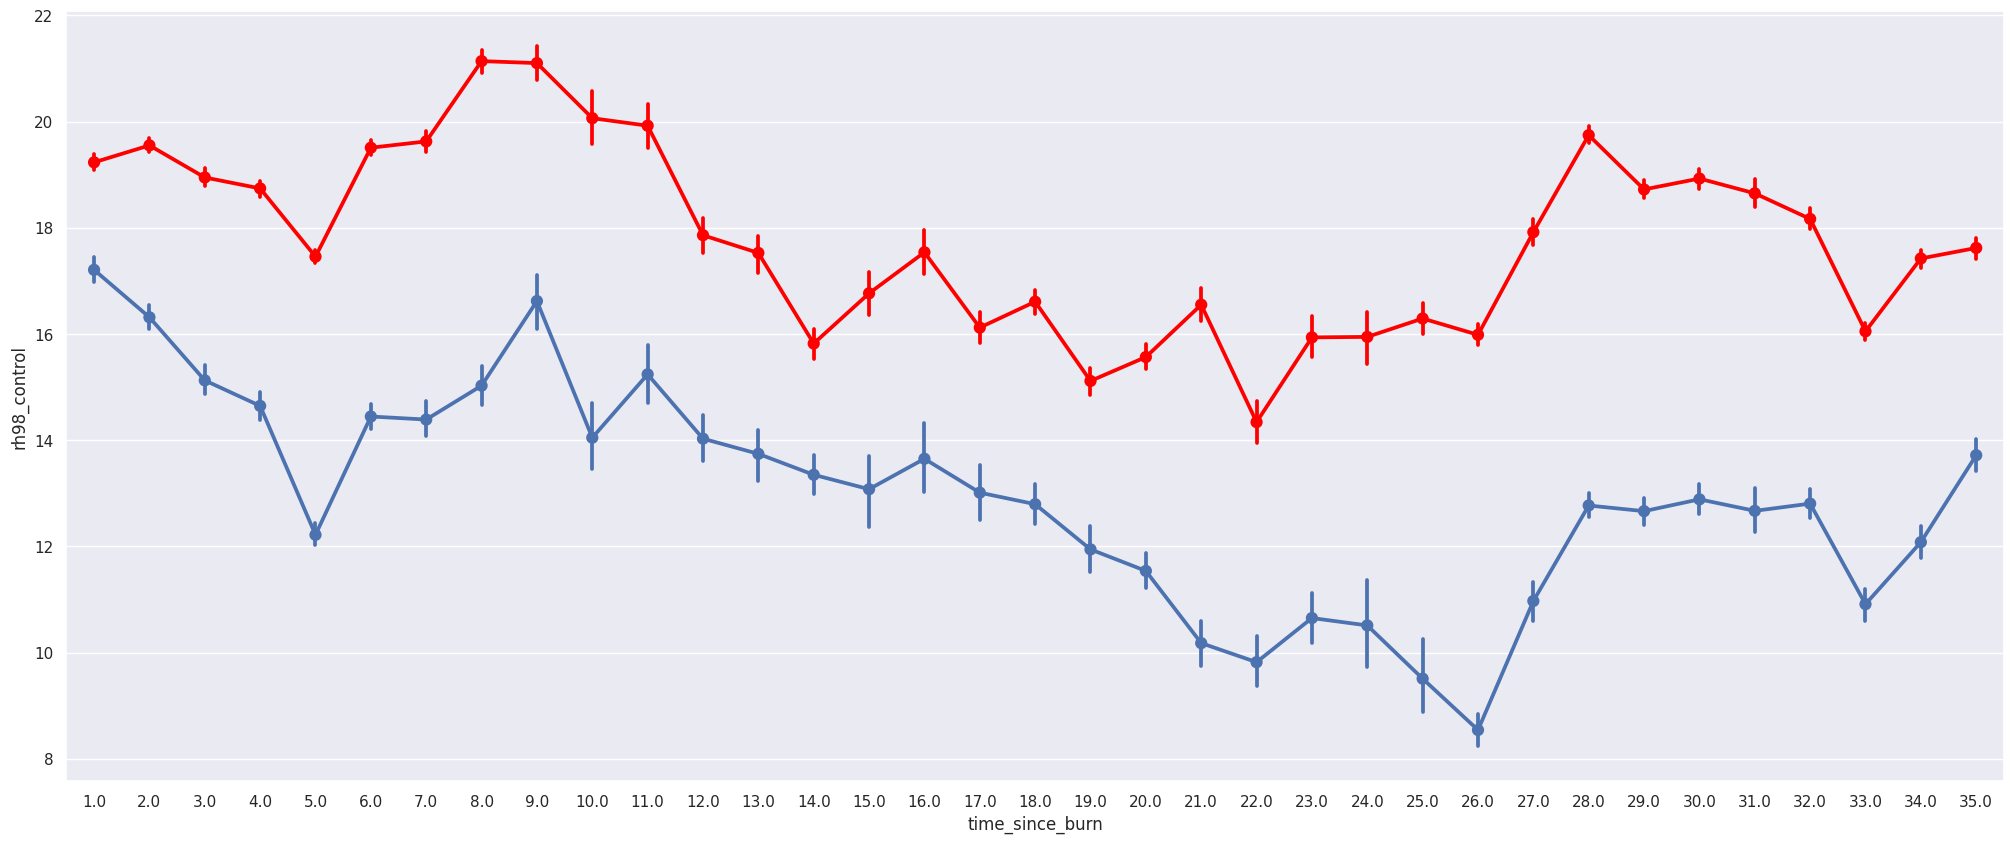

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(25, 10))
df = gedi_recovery[gedi_recovery.severity == 3]
sns.pointplot(df, x='time_since_burn', y='rh_98')
sns.pointplot(df, x='time_since_burn', y='rh98_control', color="red")

<Axes: xlabel='time_since_burn', ylabel='rh98_control'>

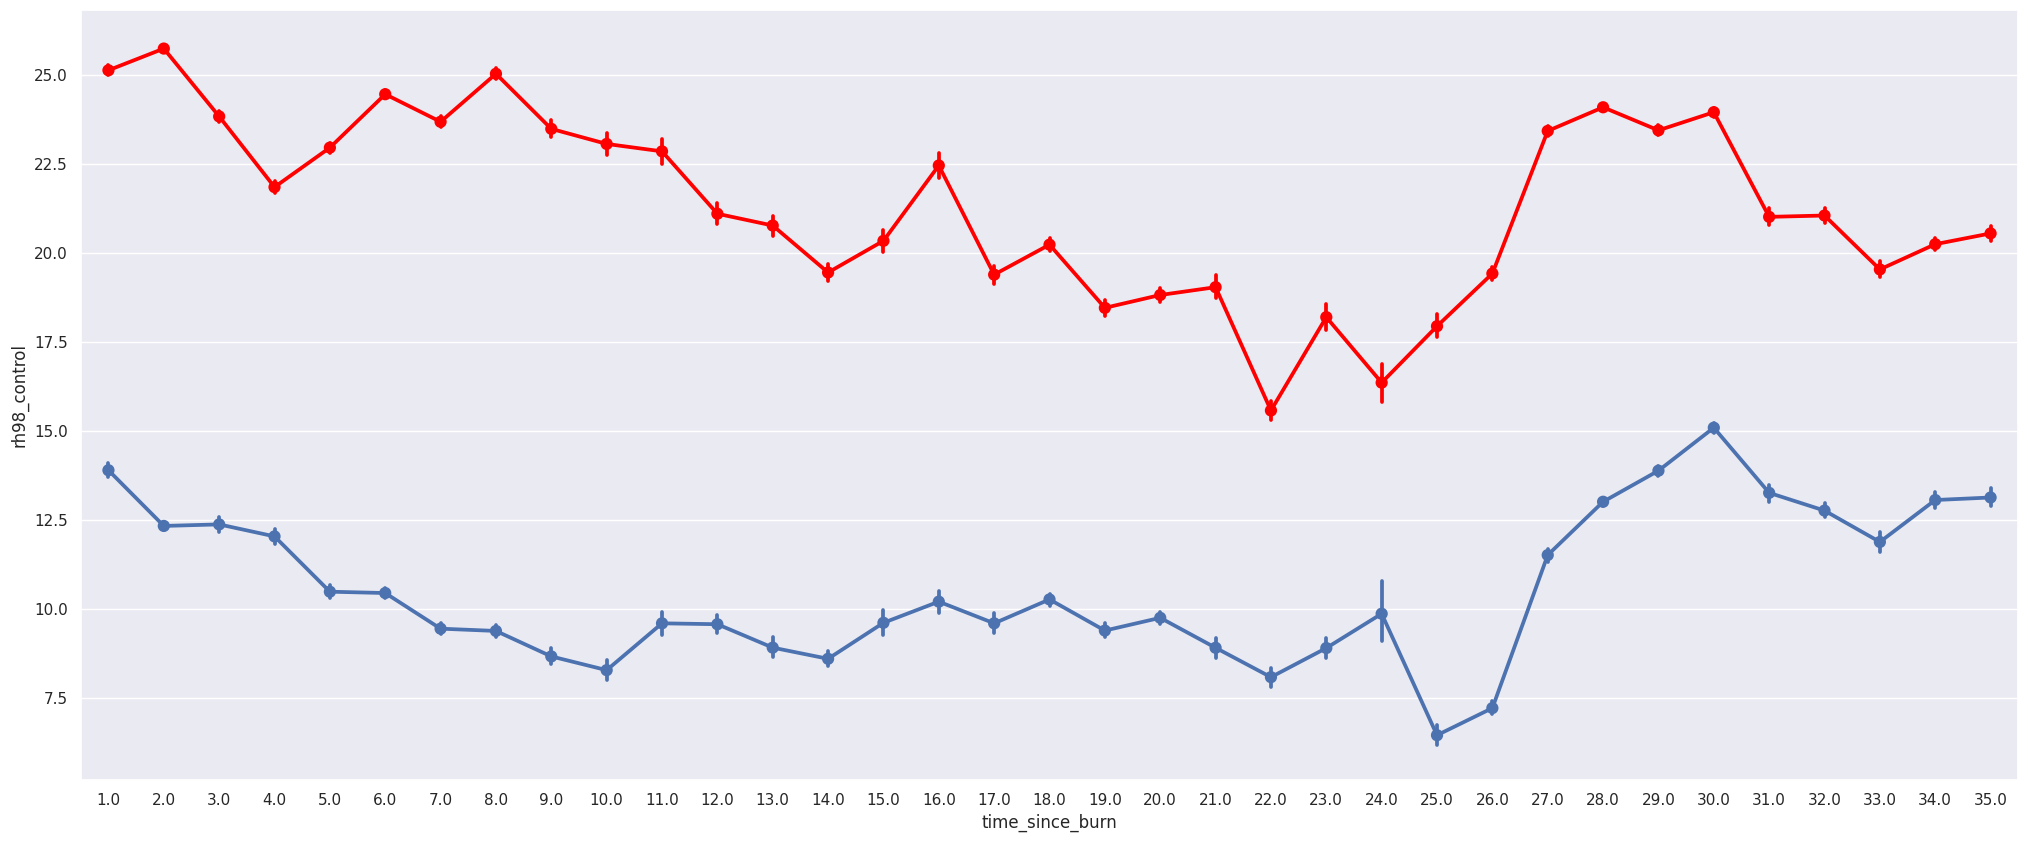

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(25, 10))
df = gedi_recovery[gedi_recovery.severity == 4]
sns.pointplot(df, x='time_since_burn', y='rh_98')
sns.pointplot(df, x='time_since_burn', y='rh98_control', color="red")

<Axes: xlabel='time_since_burn', ylabel='rh98_rel'>

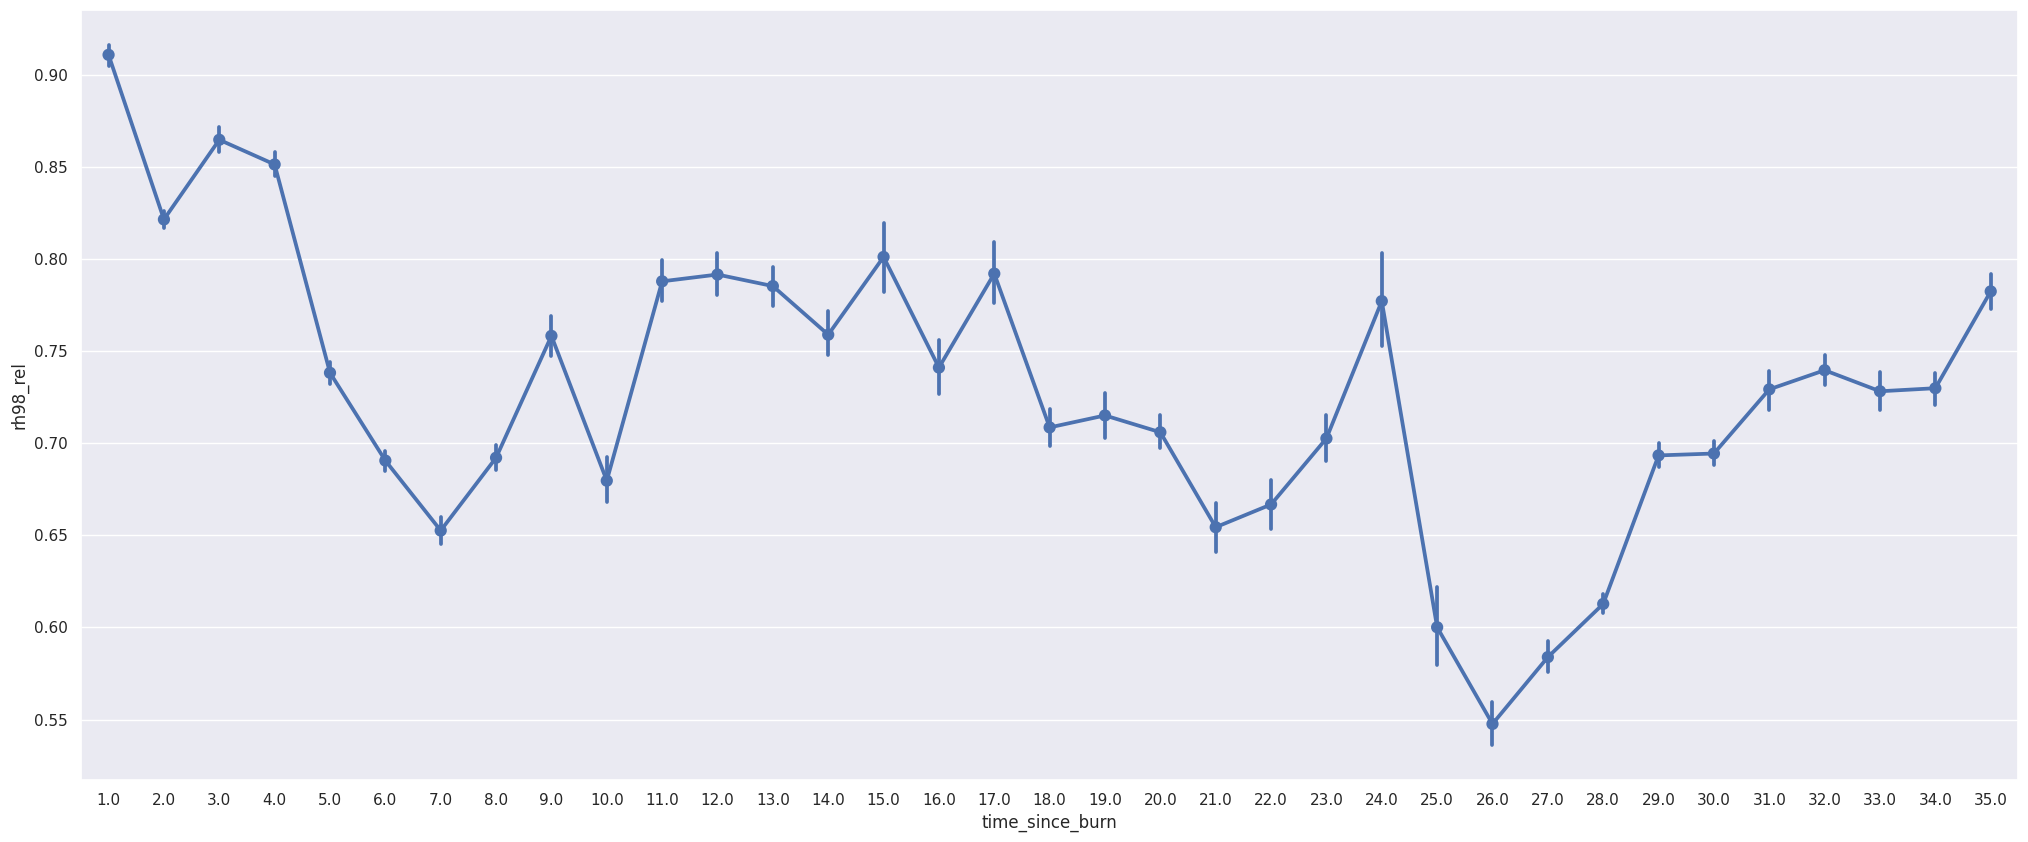

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(25, 10))
sns.pointplot(gedi_recovery, x='time_since_burn', y='rh98_rel')

<Axes: xlabel='time_since_burn', ylabel='rh98_rel'>

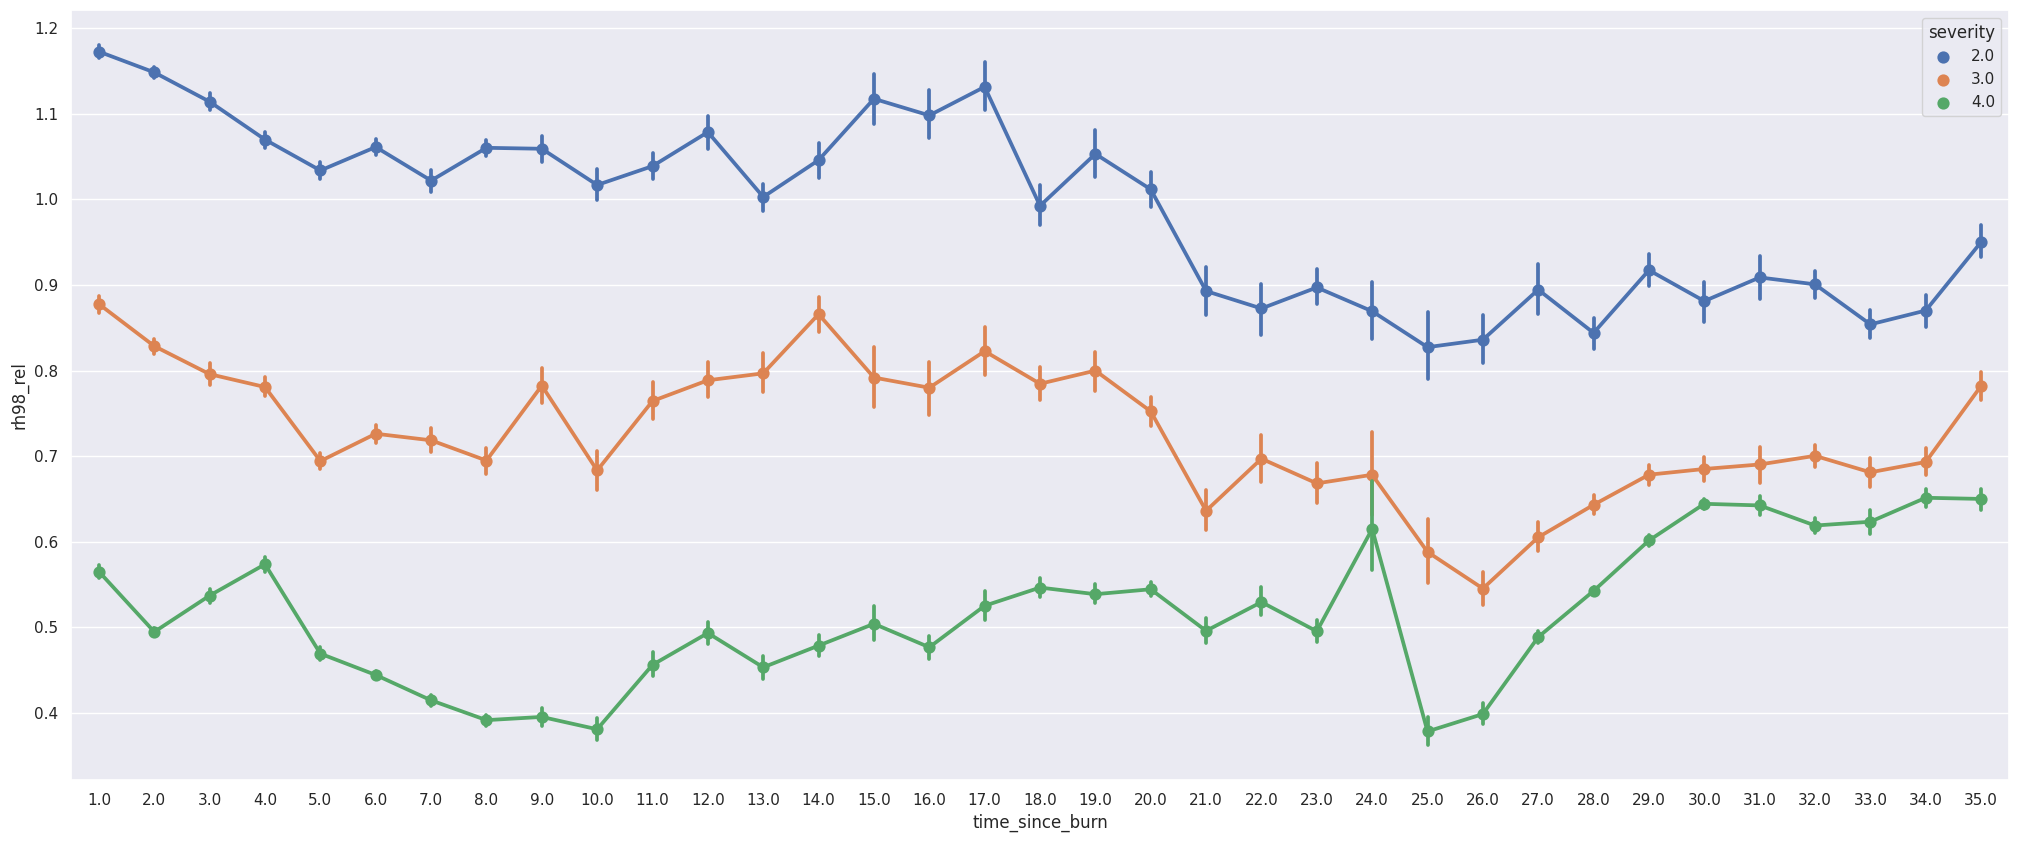

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(25, 10))
sns.pointplot(gedi_recovery, x='time_since_burn', y='rh98_rel', hue="severity")

<Axes: xlabel='time_since_burn', ylabel='rh98_rel'>

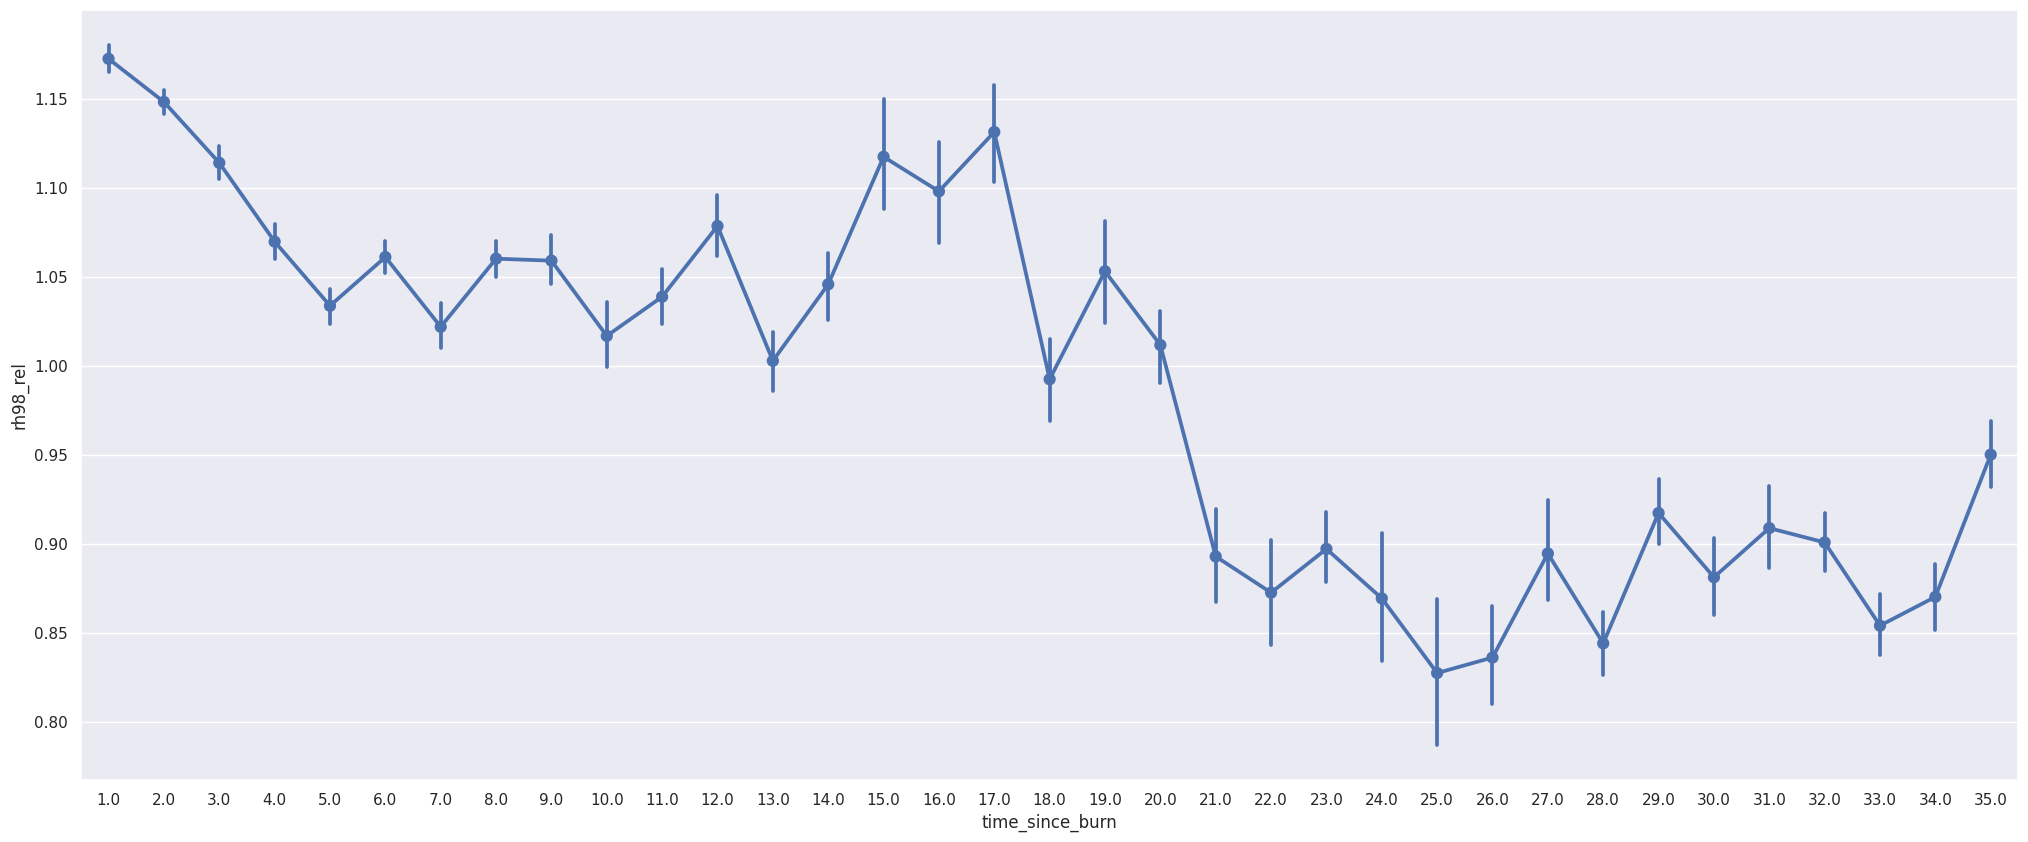

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(25, 10))
sns.pointplot(gedi_recovery[gedi_recovery.severity == 2], x='time_since_burn', y='rh98_rel')

<Axes: xlabel='time_since_burn', ylabel='rh98_rel'>

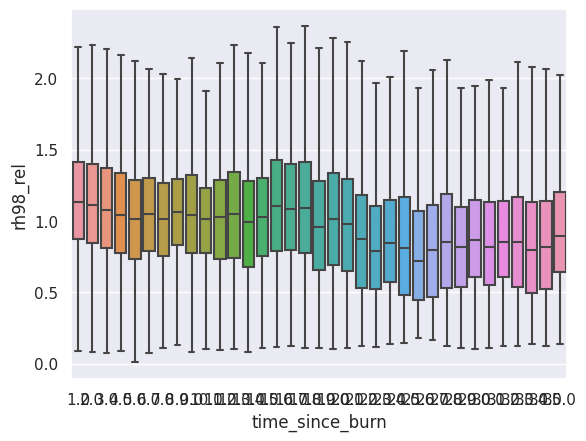

In [12]:
sns.boxplot(gedi_recovery[gedi_recovery.severity == 2], x='time_since_burn', y='rh98_rel', showfliers=False)

128541


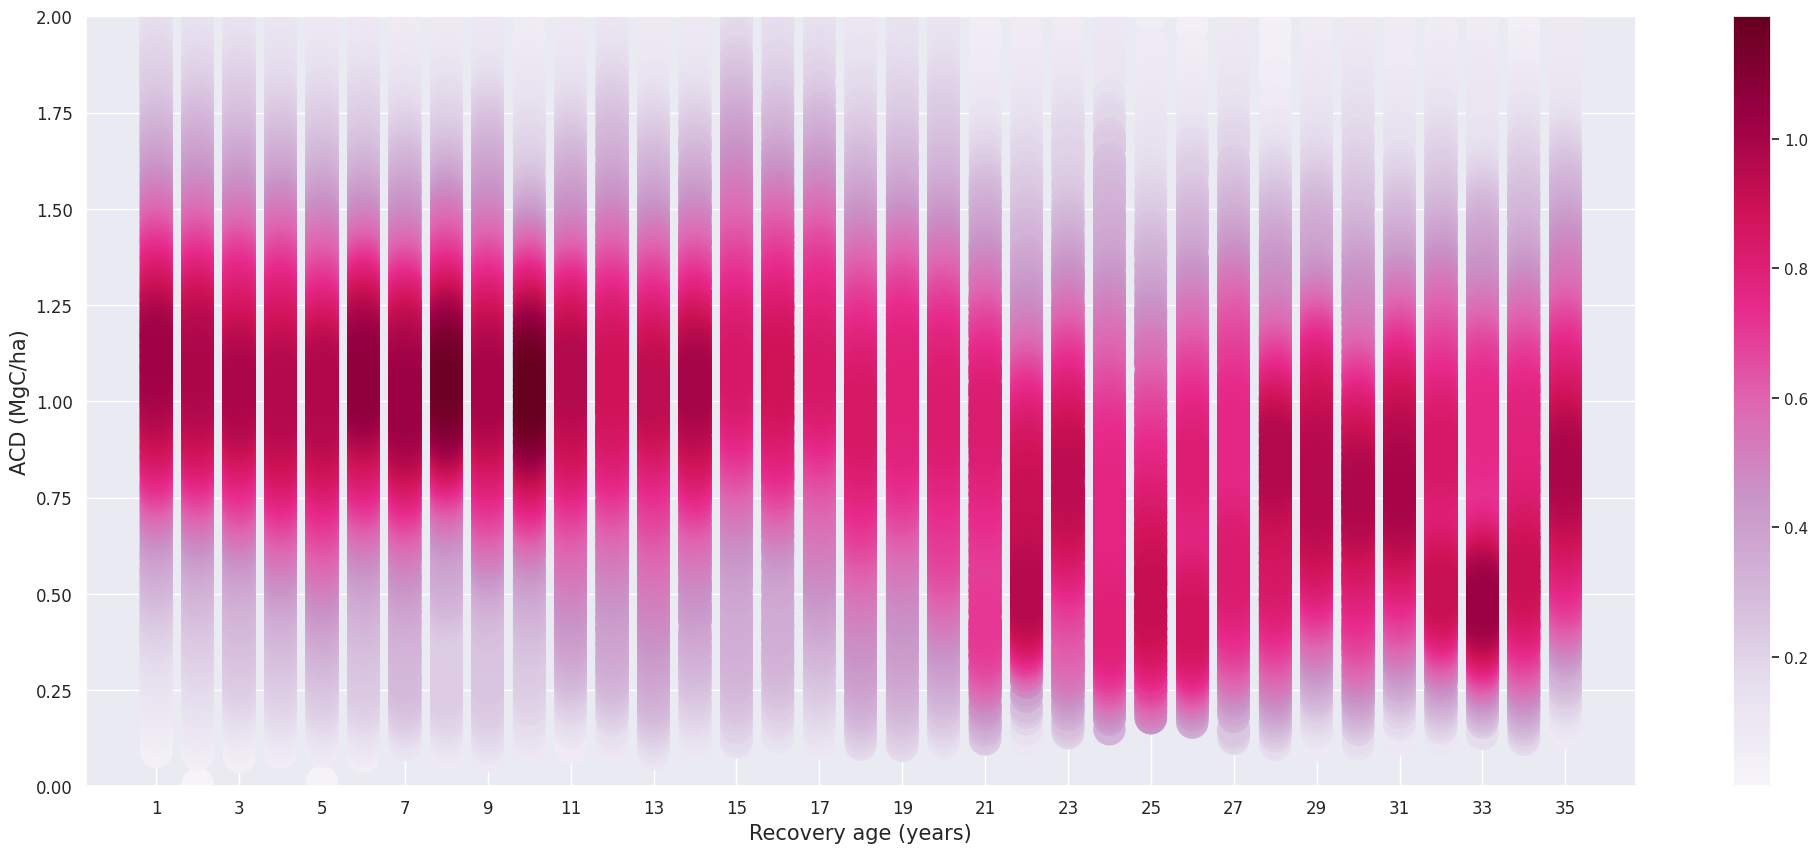

In [13]:
plot_pdf(gedi_recovery[gedi_recovery.severity == 2],
         'time_since_burn',
         'rh98_rel',
         "Recovery age (years)",
         "ACD (MgC/ha)",
         (0, 2))

94321


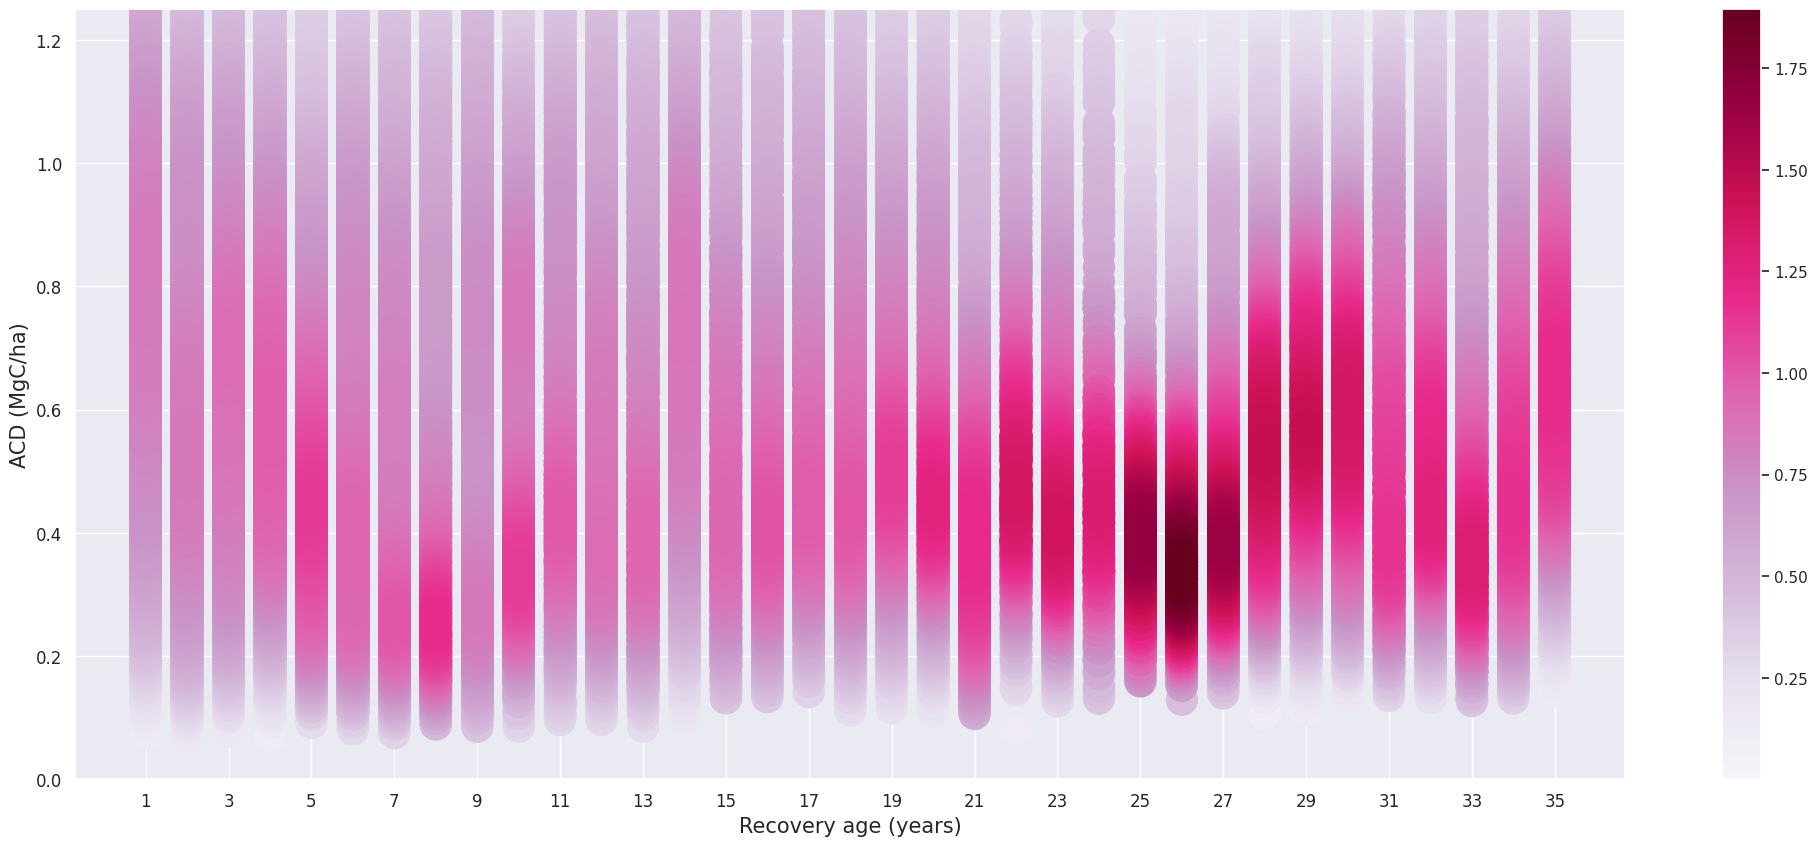

In [15]:
plot_pdf(gedi_recovery[gedi_recovery.severity == 3],
         'time_since_burn',
         'rh98_rel',
         "Recovery age (years)",
         "ACD (MgC/ha)",
         (0, 1.25))

151772


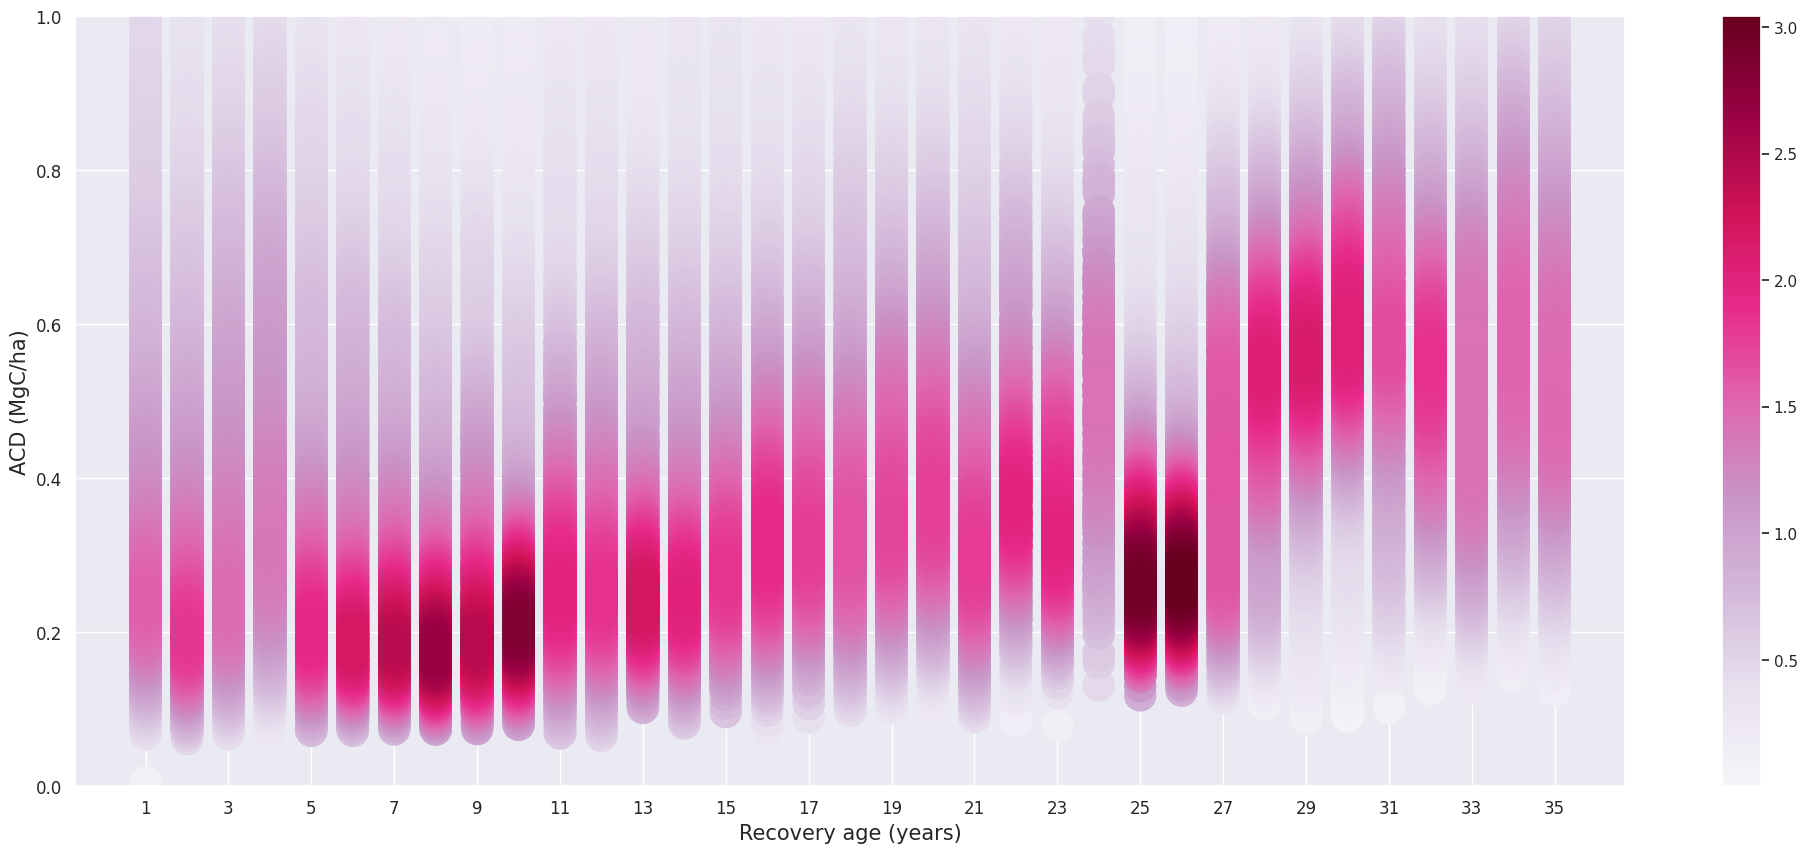

In [16]:
plot_pdf(gedi_recovery[gedi_recovery.severity == 4],
         'time_since_burn',
         'rh98_rel',
         "Recovery age (years)",
         "ACD (MgC/ha)",
         (0, 1))

In [10]:
gedi_recovery[['rh98_rel', 'slope_median']].corr()

,rh98_rel,slope_median
rh98_rel,1.000000,0.185244
slope_median,0.185244,1.000000
